# ETAPA 1: Preprocesamiento y detección de Data Leakage

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Carga de datos
df = pd.read_csv("../data/heart.csv")

# Primeras filas
print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


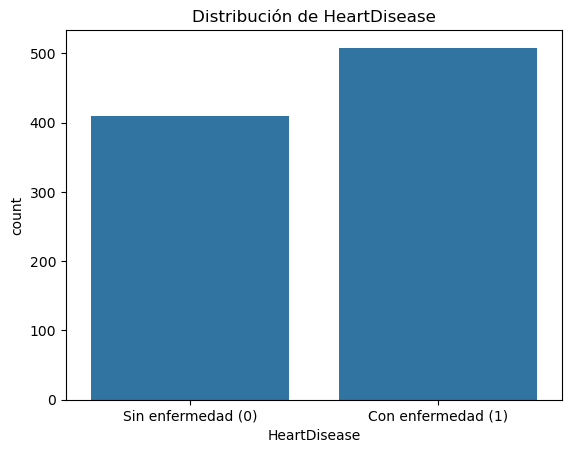

HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1    55.3
0    44.7
Name: proportion, dtype: float64


In [7]:
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribución de HeartDisease')
plt.xticks([0, 1], ['Sin enfermedad (0)', 'Con enfermedad (1)'])
plt.show()

print(df['HeartDisease'].value_counts())
print(df['HeartDisease'].value_counts(normalize=True).mul(100).round(1))

In [10]:
df_encoded = pd.get_dummies(df, columns=['Sex', 'ChestPainType', 
                                          'RestingECG', 'ExerciseAngina', 
                                          'ST_Slope'])

print("Forma después de encoding:", df_encoded.shape)
df_encoded.head()

Forma después de encoding: (918, 21)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [9]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (918, 20)
y shape: (918,)


In [13]:
# PRUEBA CON DATA LEAKAGE
np.random.seed(0)
X_leak = X.copy()
X_leak["leaky_feature"] = y + np.random.normal(0, 0.01, size=len(y))

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_leak)

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

grid_l = GridSearchCV(SVC(probability=True), 
                      param_grid={"C": [0.1, 1, 10], 
                                  "gamma": [0.01, 0.1]}, 
                      cv=5, scoring="roc_auc")
grid_l.fit(X_train_l, y_train_l)
auc_leakage = roc_auc_score(y_test_l, grid_l.predict_proba(X_test_l)[:, 1])

print("RESULTADO CON DATA LEAKAGE")
print(f"AUC: {auc_leakage:.3f}")

RESULTADO CON DATA LEAKAGE
AUC: 1.000


In [15]:
# PRUEBA SIN DATA LEAKAGE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

pipe_svc = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svc", SVC(probability=True))
])

grid = GridSearchCV(pipe_svc, 
                    param_grid={"svc__C": [0.1, 1, 10], 
                                "svc__gamma": [0.01, 0.1]}, 
                    cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)
auc_correcto = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])

print("RESULTADO SIN DATA LEAKAGE")
print(f"AUC: {auc_correcto:.3f}")
print(f"Mejores parámetros: {grid.best_params_}")

RESULTADO SIN DATA LEAKAGE
AUC: 0.924
Mejores parámetros: {'svc__C': 10, 'svc__gamma': 0.01}


In [20]:
def entrenar_modelo(nombre, pipeline, param_grid, X_train, X_test, y_train, y_test):
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    
    auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
    acc = accuracy_score(y_test, grid.predict(X_test))
    
    print(f"\n Modelo: {nombre}")
    print(f"{'='*45}")
    print(f"AUC:      {auc:.3f}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Mejores parámetros: {grid.best_params_}")
    
    return {"Modelo": nombre, "AUC": round(auc, 3), "Accuracy": round(acc, 3)}

In [21]:
resultados = []

# SVC
resultados.append({"Modelo": "SVC", 
                   "AUC": round(auc_correcto, 3), 
                   "Accuracy": round(accuracy_score(y_test, grid.predict(X_test)), 3)})

# LogisticRegression
pipe_lr = Pipeline([("scaler", StandardScaler()),
                    ("clf", LogisticRegression(max_iter=1000))])
param_lr = {"clf__C": [0.01, 0.1, 1, 10, 100]}
resultados.append(entrenar_modelo("LogisticRegression", pipe_lr, param_lr,
                                   X_train, X_test, y_train, y_test))

# RandomForestClassifier
pipe_rf = Pipeline([("scaler", MinMaxScaler()),
                    ("clf", RandomForestClassifier(random_state=42))])
param_rf = {"clf__n_estimators": [50, 100, 200],
            "clf__max_features": [3, 5, 7]}
resultados.append(entrenar_modelo("RandomForest", pipe_rf, param_rf,
                                   X_train, X_test, y_train, y_test))

# KNeighborsClassifier
pipe_knn = Pipeline([("scaler", MinMaxScaler()),
                     ("clf", KNeighborsClassifier())])
param_knn = {"clf__n_neighbors": [3, 5, 7, 9],
             "clf__weights": ["uniform", "distance"]}
resultados.append(entrenar_modelo("KNeighborsClassifier", pipe_knn, param_knn,
                                   X_train, X_test, y_train, y_test))

# GradientBoostingClassifier
pipe_gb = Pipeline([("scaler", StandardScaler()),
                    ("clf", GradientBoostingClassifier(random_state=42))])
param_gb = {"clf__n_estimators": [50, 100, 200],
            "clf__learning_rate": [0.01, 0.1, 0.2]}
resultados.append(entrenar_modelo("GradientBoosting", pipe_gb, param_gb,
                                   X_train, X_test, y_train, y_test))


 Modelo: LogisticRegression
AUC:      0.927
Accuracy: 0.864
Mejores parámetros: {'clf__C': 0.01}

 Modelo: RandomForest
AUC:      0.938
Accuracy: 0.864
Mejores parámetros: {'clf__max_features': 3, 'clf__n_estimators': 100}

 Modelo: KNeighborsClassifier
AUC:      0.920
Accuracy: 0.837
Mejores parámetros: {'clf__n_neighbors': 9, 'clf__weights': 'distance'}

 Modelo: GradientBoosting
AUC:      0.934
Accuracy: 0.886
Mejores parámetros: {'clf__learning_rate': 0.2, 'clf__n_estimators': 50}


In [23]:
# RANKING COMPARATIVO DE MODELOS
ranking = pd.DataFrame(resultados).sort_values("AUC", ascending=False)
ranking = ranking.reset_index(drop=True)
ranking.index += 1
print("\n RANKING DE MODELOS")
print(ranking.to_string())


 RANKING DE MODELOS
                 Modelo    AUC  Accuracy
1          RandomForest  0.938     0.864
2      GradientBoosting  0.934     0.886
3    LogisticRegression  0.927     0.864
4                   SVC  0.924     0.853
5  KNeighborsClassifier  0.920     0.837


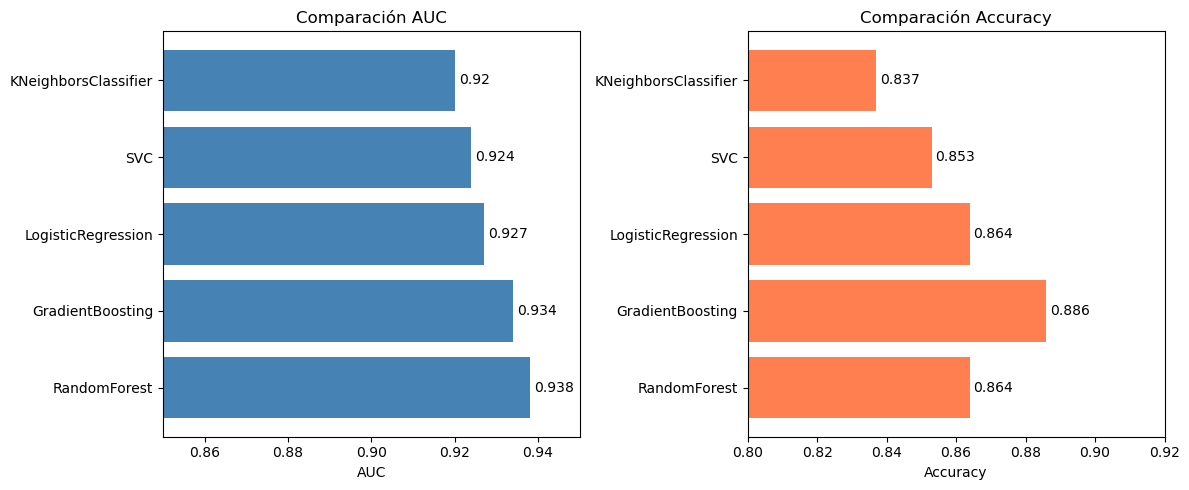

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica AUC
axes[0].barh(ranking['Modelo'], ranking['AUC'], color='steelblue')
axes[0].set_xlim(0.85, 0.95)
axes[0].set_title('Comparación AUC')
axes[0].set_xlabel('AUC')
for i, v in enumerate(ranking['AUC']):
    axes[0].text(v + 0.001, i, str(v), va='center')

# Gráfica Accuracy
axes[1].barh(ranking['Modelo'], ranking['Accuracy'], color='coral')
axes[1].set_xlim(0.80, 0.92)
axes[1].set_title('Comparación Accuracy')
axes[1].set_xlabel('Accuracy')
for i, v in enumerate(ranking['Accuracy']):
    axes[1].text(v + 0.001, i, str(v), va='center')

plt.tight_layout()
plt.savefig('../notebooks/ranking_modelos.png')
plt.show()